#  Sentiment Analysis
**Goal:** Build a complete NLP pipeline for IMDB movie reviews  
**Objective:** Predict positive or negative sentiment  
**Dataset:** Raw IMDB reviews (we will preprocess in this notebook)  
**Pipeline:** Preprocessing → Vectorization → Model → Evaluation → Custom Predictions


## 1️⃣ Data Preprocessing
We will clean the text for ML/DL models. Steps include:  
- Lowercasing  
- Removing HTML tags, punctuation & numbers  
- Tokenization  
- Stopwords removal  
- Lemmatization


In [43]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Load raw IMDB dataset
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import zipfile

zip_path = '/content/drive/MyDrive/MyDrive NLP_Projects /IMBD.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

path = "/content/IMDB Dataset.csv"
df = pd.read_csv(path)
df['sentiment']=df['sentiment'].map({
    'positive':1,
    'negative':0
})

# Initialize lemmatizer and stopwords
lemmantizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    tokens = nltk.word_tokenize(text)  # tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # remove stopwords & lemmatize
    return " ".join(tokens)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

# Inspect data
df[['review','clean_review','sentiment']].head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,1


## 2️⃣ Train/Test Split
Split the dataset into training and testing sets to avoid overfitting.


In [44]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 3️⃣ Vectorization
Convert text into numeric features using TF-IDF:
- TF-IDF weighs words by importance  
- `max_features=5000` limits vocabulary size


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Inspect shape
X_train_vec.shape


(40000, 5000)

## 4️⃣ Model Training
We train **two models** for comparison:  
1. Logistic Regression → primary model  
2. Naive Bayes (MultinomialNB) → fast, works well for text


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_vec, y_train)

# Optional: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)


MultinomialNB()

## 5️⃣ Model Evaluation
Evaluate **both models** using:  
- Accuracy  
- Confusion Matrix  
- Classification Report (Precision, Recall, F1-score)  
Compare models to see which performs better on test data.


=== Logistic Regression ===
Accuracy: 0.8854
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



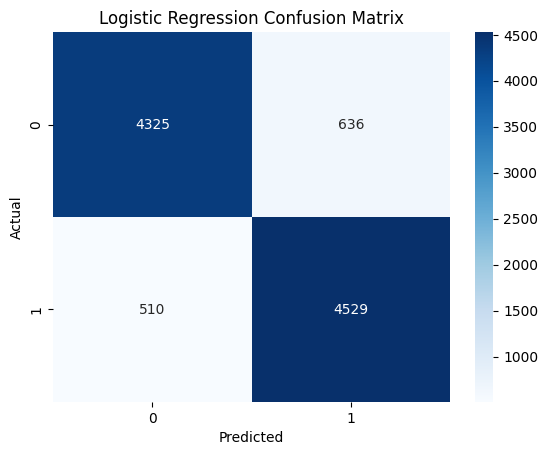

=== Naive Bayes ===
Accuracy: 0.8489
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



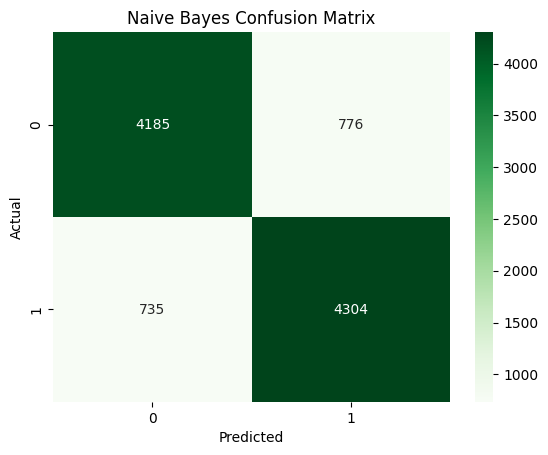

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
y_pred_lr = lr_model.predict(X_test_vec)
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Naive Bayes
y_pred_nb = nb_model.predict(X_test_vec)
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 6️⃣ Test on Custom Reviews
Check model predictions on new sample reviews.


In [48]:
sample_reviews = [
    "I absolutely loved this movie, it was amazing!",
    "This film was terrible and boring.",
    "The acting was okay but the plot was weak."
]

sample_vec = tfidf.transform(sample_reviews)
predictions_lr = lr_model.predict(sample_vec)
predictions_nb = nb_model.predict(sample_vec)

for review, lr_pred, nb_pred in zip(sample_reviews, predictions_lr, predictions_nb):
    print(f"Review: {review}")
    print(f"  Logistic Regression -> {'Positive' if lr_pred==1 else 'Negative'}")
    print(f"  Naive Bayes -> {'Positive' if nb_pred==1 else 'Negative'}")
    print("---")


Review: I absolutely loved this movie, it was amazing!
  Logistic Regression -> Positive
  Naive Bayes -> Positive
---
Review: This film was terrible and boring.
  Logistic Regression -> Negative
  Naive Bayes -> Negative
---
Review: The acting was okay but the plot was weak.
  Logistic Regression -> Negative
  Naive Bayes -> Negative
---


## 7️⃣ Conclusion
- End-to-end NLP pipeline built: Preprocessing → Vectorization → Model → Evaluation → Custom Predictions  
- Both Logistic Regression and Naive Bayes trained and evaluated  
- Confusion matrices and metrics allow performance comparison  
